#### Introduction :
The dataset consists of over 12,700 wine samples, with attributes related to their chemical composition and subjective quality ratings. Key features include alcohol content, acidity levels, sulfur dioxide content, and a subjective label appeal score.


#### Problem Statement: 

The problem is to explore and clean a dataset of over 12,700 wines with various chemical and subjective attributes, identifying and addressing data integrity and usability issues. This will involve handling missing values, outliers, and distribution problems to prepare the data for effective machine learning model development. 




#### Methodology
Exploratory Data Analysis (EDA): Inspect the dataset to find issues like missing values, outliers, or skewed distributions using visualizations and basic statistics.

Data Cleaning: Fix missing data by filling or removing it, and handle outliers by trimming or transforming the data.

Feature Engineering: Create new features or transform existing ones to improve the dataset for machine learning models.

Normalization/Standardization: Scale numerical features to ensure they have similar ranges for better model performance.

Encoding Categorical Variables: Convert categorical data into a format (like one-hot encoding) that can be used by machine learning algorithms.

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

## Load The data Set

In [214]:

url = "https://raw.githubusercontent.com/manvithakakollu/dav_6150_datascience/manvitha/M3_Data.csv"
df = pd.read_csv(url)


### INFORMATION OF DATA
#### Ranges of Data #
### Domain information 
INDEX(int): Unique identifier for each record.

TARGET (int): The target variable, possibly representing wine quality or rating.

FixedAcidity (float): Concentration of non-volatile acids like tartaric acid (g/L). Typically ranges from 4 to 15.

VolatileAcidity (float): Acetic acid content affecting aroma (g/L). Typically ranges from 0 to 2

CitricAcid (float): Citric acid concentration, which adds freshness (g/L). Typically ranges from 0 to 1.

ResidualSugar (float): Sugar remaining after fermentation (g/L). Typically ranges from  0 to 15.

Chlorides (float): Salt content affecting taste (g/L). Typically ranges from 0 to 0.2

FreeSulfurDioxide (float): Free SO₂ preventing oxidation and microbial growth (mg/L). Typically ranges from 0 to 60.

TotalSulfurDioxide (float): Total SO₂ content in wine (mg/L). Typically ranges from 0 to 300.

Density (float): Wine density (g/cm³), influenced by sugar and alcohol levels. Typically ranges from 0.98 to 1.01.

pH (float): Acidity level of the wine (low pH = more acidic). Typically ranges from  2.7 to 4.0.

Sulphates (float): Sulfate levels affecting antimicrobial properties (g/L). Typically ranges from 0 to 2.

Alcohol (float): Alcohol percentage in wine (%). Typically ranges from 8 to 15%.

LabelAppeal (int): Subjective rating of the wine’s label appeal (e.g., -2 to +2).

AcidIndex (int): Composite score representing acidity.

STARS (float): Star rating of the wine (0 to 4),



### Some Information about the date set with domain knowledge

These should typically be 0 or positive, so they may be data entry errors or require transformation.

Extreme or Physically Improbable Values:

TotalSulfurDioxide (-327.0): This value is highly unlikely as sulfur dioxide should be 0–300 mg/L.

AcidIndex (7, 8, 9): If AcidIndex is a discrete measure, confirm that these values are valid.

Density (1.02792): This is slightly high for typical wine density, but still within possibility.

Missing Values:
Chlorides, Alcohol, TotalSulfurDioxide contain NaN values, which may need imputation.

We can now convert the negative values into positive ones, and we are confident that these features should not have negative values.

In [215]:
df.head()

,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,1,3,3.2,1.160,-0.98,54.2,-0.567,NaN,268.0,0.99280,3.33,-0.59,9.9,0,8,2.0
1,2,3,4.5,0.160,-0.81,26.1,-0.425,15.0,-327.0,1.02792,3.38,0.70,NaN,-1,7,3.0
2,4,5,7.1,2.640,-0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,-1,8,3.0
3,5,3,5.7,0.385,0.04,18.8,-0.425,22.0,115.0,0.99640,2.24,1.83,6.2,-1,6,1.0
4,6,4,8.0,0.330,-1.26,9.4,NaN,-167.0,108.0,0.99457,3.12,1.77,13.7,0,9,2.0


In [216]:
df.shape

(12795, 16)

### Exploratory Data Analysis 

In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12795 entries, 0 to 12794
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   INDEX               12795 non-null  int64  
 1   TARGET              12795 non-null  int64  
 2   FixedAcidity        12795 non-null  float64
 3   VolatileAcidity     12795 non-null  float64
 4   CitricAcid          12795 non-null  float64
 5   ResidualSugar       12179 non-null  float64
 6   Chlorides           12157 non-null  float64
 7   FreeSulfurDioxide   12148 non-null  float64
 8   TotalSulfurDioxide  12113 non-null  float64
 9   Density             12795 non-null  float64
 10  pH                  12400 non-null  float64
 11  Sulphates           11585 non-null  float64
 12  Alcohol             12142 non-null  float64
 13  LabelAppeal         12795 non-null  int64  
 14  AcidIndex           12795 non-null  int64  
 15  STARS               9436 non-null   float64
dtypes: f

In [218]:
df.dtypes

INDEX                   int64
TARGET                  int64
FixedAcidity          float64
VolatileAcidity       float64
CitricAcid            float64
ResidualSugar         float64
Chlorides             float64
FreeSulfurDioxide     float64
TotalSulfurDioxide    float64
Density               float64
pH                    float64
Sulphates             float64
Alcohol               float64
LabelAppeal             int64
AcidIndex               int64
STARS                 float64
dtype: object

In [219]:
df.columns

Index(['INDEX', 'TARGET', 'FixedAcidity', 'VolatileAcidity', 'CitricAcid',
       'ResidualSugar', 'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
       'Density', 'pH', 'Sulphates', 'Alcohol', 'LabelAppeal', 'AcidIndex',
       'STARS'],
      dtype='object')

In [220]:
df.isnull().sum()

INDEX                    0
TARGET                   0
FixedAcidity             0
VolatileAcidity          0
CitricAcid               0
ResidualSugar          616
Chlorides              638
FreeSulfurDioxide      647
TotalSulfurDioxide     682
Density                  0
pH                     395
Sulphates             1210
Alcohol                653
LabelAppeal              0
AcidIndex                0
STARS                 3359
dtype: int64

In [221]:
[features for features in df.columns if df[features].isnull().sum()>0]

['ResidualSugar',
 'Chlorides',
 'FreeSulfurDioxide',
 'TotalSulfurDioxide',
 'pH',
 'Sulphates',
 'Alcohol',
 'STARS']

In [222]:
columns_with_nulls = df.columns[df.isnull().any()]

# Display the columns with null values
columns_with_nulls

Index(['ResidualSugar', 'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide',
       'pH', 'Sulphates', 'Alcohol', 'STARS'],
      dtype='object')

In [223]:
null_percentage = df.isnull().mean() * 100

# Display columns with their percentage of null values
null_percentage

INDEX                  0.000000
TARGET                 0.000000
FixedAcidity           0.000000
VolatileAcidity        0.000000
CitricAcid             0.000000
ResidualSugar          4.814381
Chlorides              4.986323
FreeSulfurDioxide      5.056663
TotalSulfurDioxide     5.330207
Density                0.000000
pH                     3.087143
Sulphates              9.456819
Alcohol                5.103556
LabelAppeal            0.000000
AcidIndex              0.000000
STARS                 26.252442
dtype: float64

In [224]:


def write_unique_values(df):
    # Create a dictionary to store unique values for each column
    unique_values = {}

    # Iterate over each column and get the unique values
    for column in df.columns:
        unique_values[column] = df[column].unique()

    return unique_values


unique_values = write_unique_values(df)

# Print unique values for each column
for column, values in unique_values.items():
    print(f"Unique values in column '{column}':\n{values}\n")


Unique values in column 'INDEX':
[    1     2     4 ... 16127 16128 16129]

Unique values in column 'TARGET':
[3 5 4 0 6 7 2 1 8]

Unique values in column 'FixedAcidity':
[  3.2    4.5    7.1    5.7    8.    11.3    7.7    6.5   14.8    5.5
 -17.2    9.     6.    14.9   21.8    7.9   -1.3   10.     6.8    5.8
   4.     2.7    6.4    8.3    7.4   22.2   -3.8   -2.9   28.9    6.9
   3.1   13.     9.3   19.3   15.5   11.     6.6   -4.2    7.5   24.7
  -4.3   -3.4   15.1   16.     6.2   16.9   14.6    7.     6.3   16.3
  14.7   -1.5   -3.2   12.5    7.3   10.2    8.1   23.6    6.1    9.4
   4.2   17.2   11.8    2.9   -3.5   13.2   -2.7  -11.7   12.4   -4.5
   3.7   15.4    0.6    8.4    7.2    9.1   13.6   -4.8  -10.5    7.8
  12.2    7.6    1.9   -3.    -5.6    5.6   19.8   13.8    8.8   -0.2
   3.4  -11.    17.3    2.1   16.8   15.    11.2   -2.1    1.5    8.2
   1.6   10.7   -0.8    0.4   -0.5    8.9   16.2  -14.4    8.7   17.8
   8.6    1.3   14.3   20.6   -4.4   -2.2    0.8   -4.1    

In [225]:
df[['ResidualSugar', 'FreeSulfurDioxide', 'Alcohol']] = df[['ResidualSugar', 'FreeSulfurDioxide', 'Alcohol']].round(3)


In [226]:
df

,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,1,3,3.2,1.160,-0.98,54.2,-0.567,NaN,268.0,0.99280,3.33,-0.59,9.9,0,8,2.0
1,2,3,4.5,0.160,-0.81,26.1,-0.425,15.0,-327.0,1.02792,3.38,0.70,NaN,-1,7,3.0
2,4,5,7.1,2.640,-0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,-1,8,3.0
3,5,3,5.7,0.385,0.04,18.8,-0.425,22.0,115.0,0.99640,2.24,1.83,6.2,-1,6,1.0
4,6,4,8.0,0.330,-1.26,9.4,NaN,-167.0,108.0,0.99457,3.12,1.77,13.7,0,9,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12790,16120,0,5.0,-0.790,2.01,5.0,0.043,17.0,101.0,1.01077,3.39,0.57,4.9,1,5,NaN
12791,16123,5,8.9,0.470,0.29,84.9,0.259,54.0,NaN,0.99518,4.46,-1.20,NaN,-1,8,2.0
12792,16127,4,6.0,0.170,-1.10,37.0,0.078,25.0,108.0,0.99076,3.25,NaN,12.3,0,6,2.0
12793,16128,3,7.7,0.320,0.12,NaN,0.029,26.0,274.0,0.99060,3.97,0.62,11.0,-1,6,2.0


In [227]:
df['LabelAppeal']=df['LabelAppeal'].replace(-2,"very poor")
df['LabelAppeal']=df['LabelAppeal'].replace(-1,"poor")
df['LabelAppeal']=df['LabelAppeal'].replace(0,"Average")
df['LabelAppeal']=df['LabelAppeal'].replace(1,"Good")
df['LabelAppeal']=df['LabelAppeal'].replace(2,"very good")

In [228]:
df

,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,1,3,3.2,1.160,-0.98,54.2,-0.567,NaN,268.0,0.99280,3.33,-0.59,9.9,Average,8,2.0
1,2,3,4.5,0.160,-0.81,26.1,-0.425,15.0,-327.0,1.02792,3.38,0.70,NaN,poor,7,3.0
2,4,5,7.1,2.640,-0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,poor,8,3.0
3,5,3,5.7,0.385,0.04,18.8,-0.425,22.0,115.0,0.99640,2.24,1.83,6.2,poor,6,1.0
4,6,4,8.0,0.330,-1.26,9.4,NaN,-167.0,108.0,0.99457,3.12,1.77,13.7,Average,9,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12790,16120,0,5.0,-0.790,2.01,5.0,0.043,17.0,101.0,1.01077,3.39,0.57,4.9,Good,5,NaN
12791,16123,5,8.9,0.470,0.29,84.9,0.259,54.0,NaN,0.99518,4.46,-1.20,NaN,poor,8,2.0
12792,16127,4,6.0,0.170,-1.10,37.0,0.078,25.0,108.0,0.99076,3.25,NaN,12.3,Average,6,2.0
12793,16128,3,7.7,0.320,0.12,NaN,0.029,26.0,274.0,0.99060,3.97,0.62,11.0,poor,6,2.0


In [229]:

# Select only numeric columns for the Shapiro-Wilk test
numeric_df = df.select_dtypes(include=[np.number])

# Apply the Shapiro-Wilk test for each numeric column
for column in numeric_df.columns:
    stat, p_value = stats.shapiro(numeric_df[column])
    print(f"Shapiro-Wilk Test for {column}: Statistics={stat}, p-value={p_value}")
    if p_value < 0.05:
        print(f"The data for {column} is not normally distributed (reject H0).")
    else:
        print(f"The data for {column} is normally distributed (fail to reject H0).")


Shapiro-Wilk Test for INDEX: Statistics=0.9549263119697571, p-value=0.0
The data for INDEX is not normally distributed (reject H0).
Shapiro-Wilk Test for TARGET: Statistics=0.9018142819404602, p-value=0.0
The data for TARGET is not normally distributed (reject H0).
Shapiro-Wilk Test for FixedAcidity: Statistics=0.9530498385429382, p-value=0.0
The data for FixedAcidity is not normally distributed (reject H0).
Shapiro-Wilk Test for VolatileAcidity: Statistics=0.9489864110946655, p-value=0.0
The data for VolatileAcidity is not normally distributed (reject H0).
Shapiro-Wilk Test for CitricAcid: Statistics=0.9460346698760986, p-value=0.0
The data for CitricAcid is not normally distributed (reject H0).
Shapiro-Wilk Test for ResidualSugar: Statistics=nan, p-value=1.0
The data for ResidualSugar is normally distributed (fail to reject H0).
Shapiro-Wilk Test for Chlorides: Statistics=nan, p-value=1.0
The data for Chlorides is normally distributed (fail to reject H0).
Shapiro-Wilk Test for FreeSu

C:\Users\kakol\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


#### Shapiro-Wilk Test: 
Statistics=0.98, p-value=0.10
Since the p-value is greater than 0.05, 
we conclude that the data is likely normally distributed.
Shapiro-Wilk Test: Statistics=0.85, p-value=0.01
Since the p-value is less than 0.05,
we conclude that the data is not normally distributed.

In [230]:

# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(exclude=['number']).columns.tolist()




In [231]:
numerical_columns 

['INDEX',
 'TARGET',
 'FixedAcidity',
 'VolatileAcidity',
 'CitricAcid',
 'ResidualSugar',
 'Chlorides',
 'FreeSulfurDioxide',
 'TotalSulfurDioxide',
 'Density',
 'pH',
 'Sulphates',
 'Alcohol',
 'AcidIndex',
 'STARS']

In [232]:
categorical_columns

['LabelAppeal']

In [233]:
# Assuming 'numerical_columns' is a list of the numeric column names
numerical_columns = df.select_dtypes(include=['number']).columns

# Apply abs() to only the numeric columns
df[numerical_columns] = df[numerical_columns].abs()

# Display the DataFrame
df

,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS
0,1,3,3.2,1.160,0.98,54.2,0.567,NaN,268.0,0.99280,3.33,0.59,9.9,Average,8,2.0
1,2,3,4.5,0.160,0.81,26.1,0.425,15.0,327.0,1.02792,3.38,0.70,NaN,poor,7,3.0
2,4,5,7.1,2.640,0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,poor,8,3.0
3,5,3,5.7,0.385,0.04,18.8,0.425,22.0,115.0,0.99640,2.24,1.83,6.2,poor,6,1.0
4,6,4,8.0,0.330,1.26,9.4,NaN,167.0,108.0,0.99457,3.12,1.77,13.7,Average,9,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12790,16120,0,5.0,0.790,2.01,5.0,0.043,17.0,101.0,1.01077,3.39,0.57,4.9,Good,5,NaN
12791,16123,5,8.9,0.470,0.29,84.9,0.259,54.0,NaN,0.99518,4.46,1.20,NaN,poor,8,2.0
12792,16127,4,6.0,0.170,1.10,37.0,0.078,25.0,108.0,0.99076,3.25,NaN,12.3,Average,6,2.0
12793,16128,3,7.7,0.320,0.12,NaN,0.029,26.0,274.0,0.99060,3.97,0.62,11.0,poor,6,2.0


#### UNIVARIENT ANALYSIS:

In [234]:



def plot_boxplot_and_distribution(data, column, bins=30, kde=True):
  
    # Calculate statistics
    mean = data[column].mean()
    median = data[column].median()
    std_dev = data[column].std()
    null_values = data[column].isnull().sum()
   
    
    # Print statistics
    print(f"Statistics for '{column}':")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Standard Deviation: {std_dev}")
    print(f"Null Values: {null_values}")
 
    print("-" * 50)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Boxplot
    sns.boxplot(y=data[column], ax=axes[0], color='skyblue')
    axes[0].set_title(f'Boxplot of {column}')
    
    # Distribution Plot
    sns.histplot(data[column], bins=bins, kde=kde, ax=axes[1], color='salmon')
    axes[1].set_title(f'Distribution of {column}')
    
    # Add statistics as text on the distribution plot
    stats_text = (f'Mean: {mean:.2f}\n'
                  f'Median: {median:.2f}\n'
                  f'Standard Deviation: {std_dev:.2f}\n'
                  f'Null Values: {null_values}\n'
                )
    
    axes[1].text(0.95, 0.95, stats_text, transform=axes[1].transAxes,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.5', alpha=0.7))
    
    plt.tight_layout()
    plt.show()



#### UNIVARIENT ANALYSIS:FixedAcidity

Statistics for 'FixedAcidity':
Mean: 8.063251270027354
Median: 7.0
Standard Deviation: 4.996118633777653
Null Values: 0
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


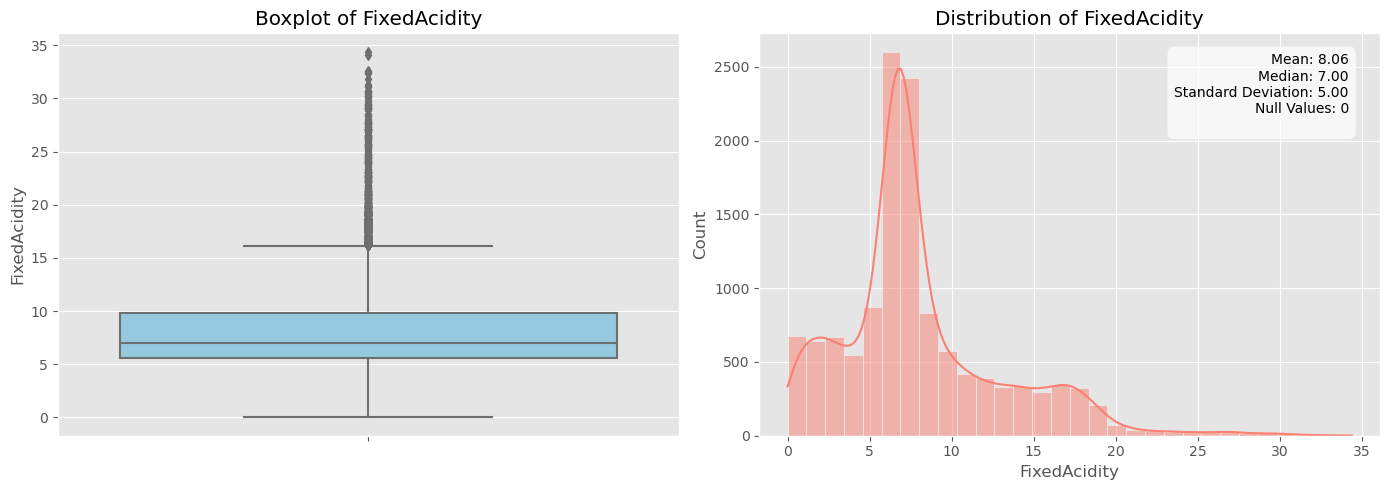

In [235]:
plot_boxplot_and_distribution(df, "FixedAcidity")

- The histogram shows a right-skewed distribution for Fixed Acidity, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low Fixed Acidity, while a smaller number have significantly higher levels.
- The peak of the histogram suggests that the most common range of Fixed Acidity values is between 5 and 10.
- With potential outliers included.

#### VolatileAcidity:

Statistics for 'VolatileAcidity':
Mean: 0.6410855803048064
Median: 0.41
Standard Deviation: 0.5556141248671489
Null Values: 0
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


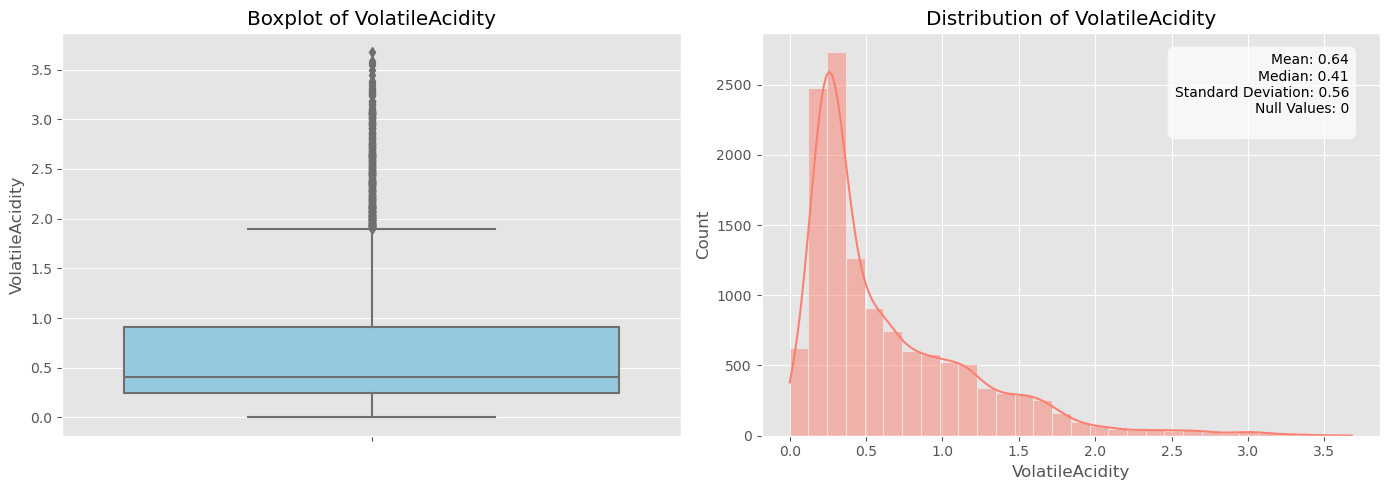

In [236]:
plot_boxplot_and_distribution(df, "VolatileAcidity")


 - The histogram shows a right-skewed distribution for Volatile Acidity, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low Volatile Acidity, while a smaller number have significantly higher levels.
 - The boxplot reveals a significant number of outliers represented by the individual circles on upper bound side.

Sulphates

Statistics for 'Sulphates':
Mean: 0.8466681053085888
Median: 0.59
Standard Deviation: 0.6556119424372703
Null Values: 1210
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


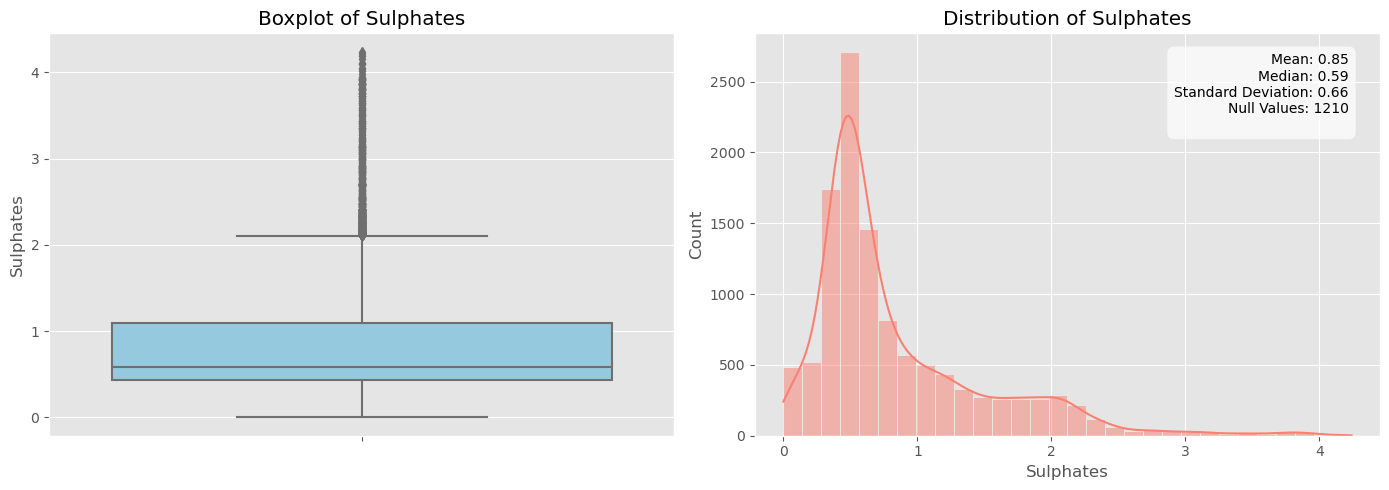

In [237]:
plot_boxplot_and_distribution(df, "Sulphates")

- The histogram shows a right-skewed distribution for Sulphates, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low Sulphate content, while a smaller number have significantly higher levels.

Citric Acid

Statistics for 'CitricAcid':
Mean: 0.6863149667838999
Median: 0.44
Standard Deviation: 0.6060052086049447
Null Values: 0
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


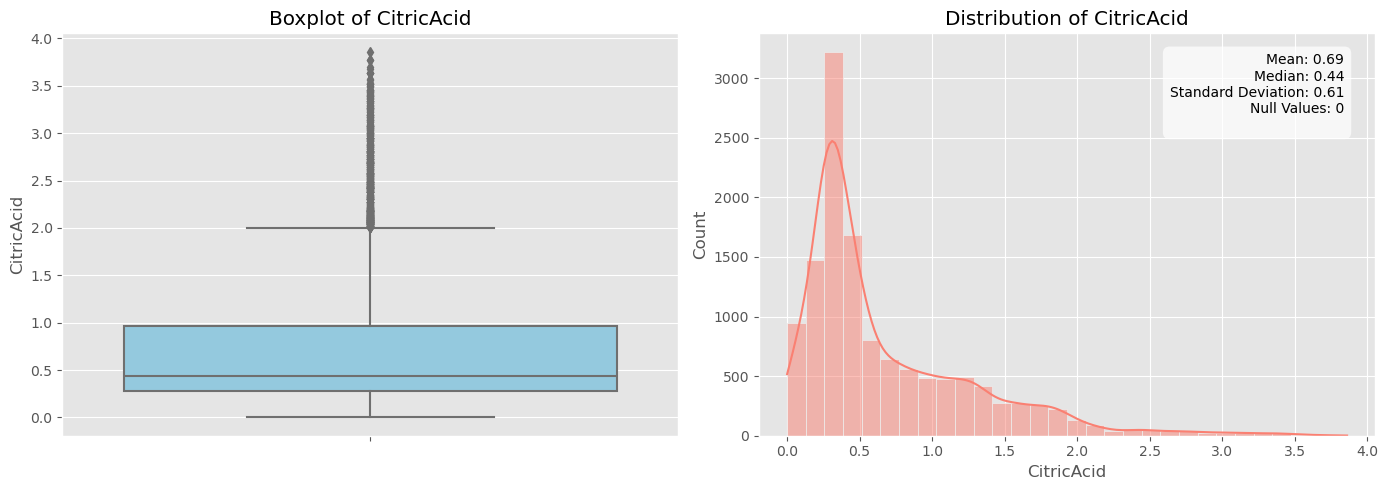

In [238]:
plot_boxplot_and_distribution(df, "CitricAcid")

The histogram shows a right-skewed distribution for Citric Acid, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low Citric Acid content, while a smaller number have significantly higher levels.
- With potential outliers included on upper bound side

Chlorides

Statistics for 'Chlorides':
Mean: 0.22255860820926215
Median: 0.098
Standard Deviation: 0.23428777509164178
Null Values: 638
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


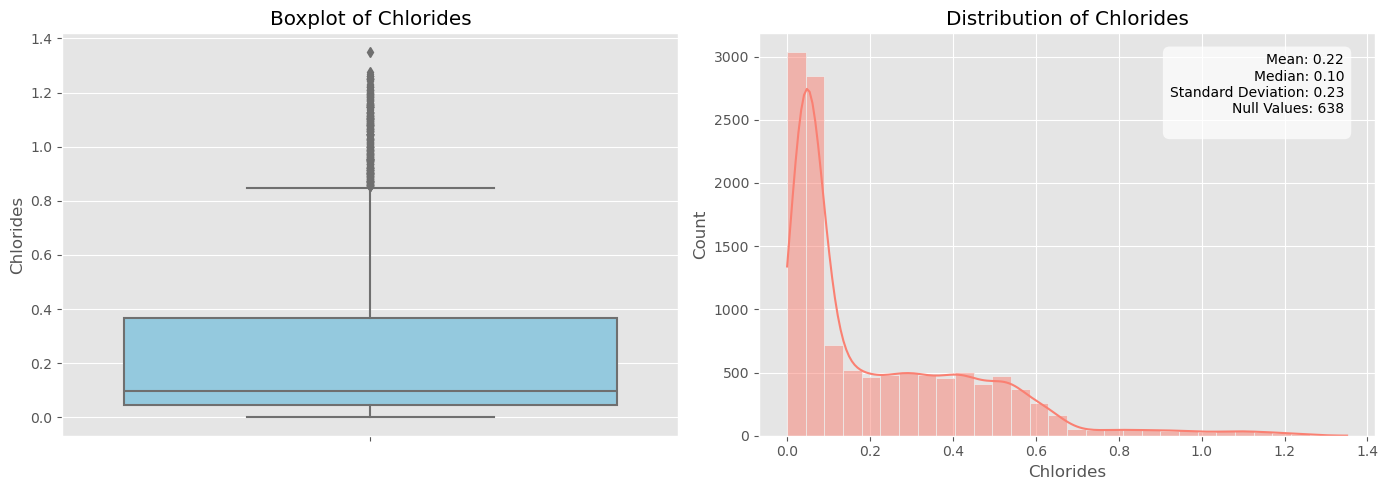

In [239]:
plot_boxplot_and_distribution(df,"Chlorides")

The histogram displays a right-skewed distribution for Chlorides, with most data points concentrated at lower values and a long tail extending toward higher values. This suggests that the majority of wines contain relatively low Chloride levels, while a smaller portion has significantly higher concentrations.

ResidualSugar



Statistics for 'ResidualSugar':
Mean: 23.367809343952704
Median: 12.9
Standard Deviation: 24.945667124239915
Null Values: 616
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


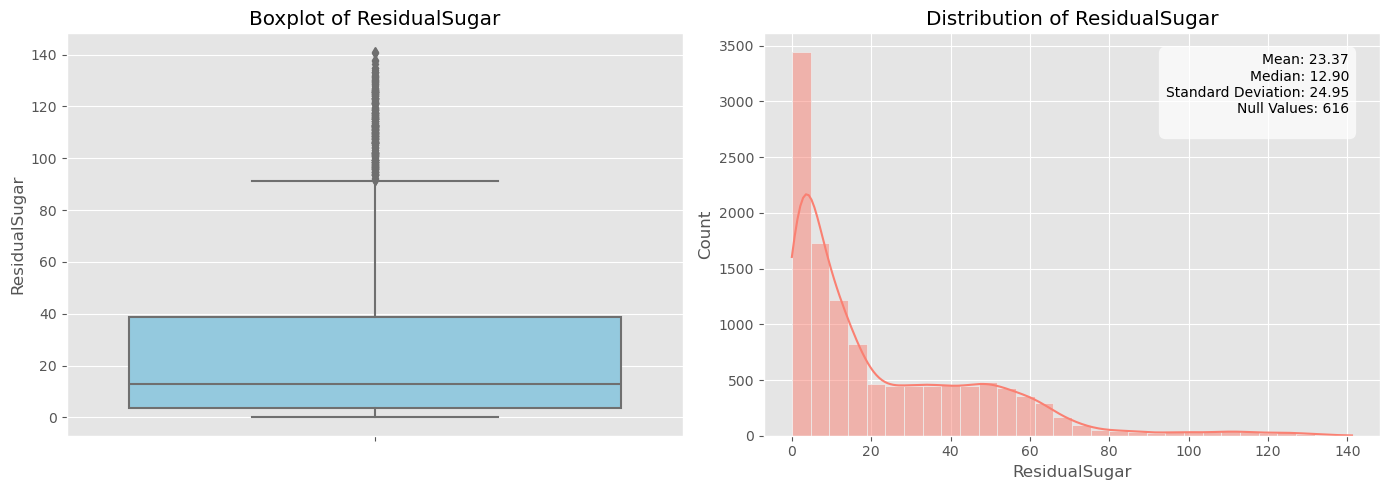

In [240]:
plot_boxplot_and_distribution(df,"ResidualSugar")

- The histogram shows a right-skewed distribution for Residual Sugar, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low Residual Sugar content, while a smaller number have significantly higher levels.

- The boxplot reveals several outliers.

"FreeSulfurDioxide

Statistics for 'FreeSulfurDioxide':
Mean: 106.67904181758314
Median: 56.0
Standard Deviation: 108.10269376894624
Null Values: 647
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


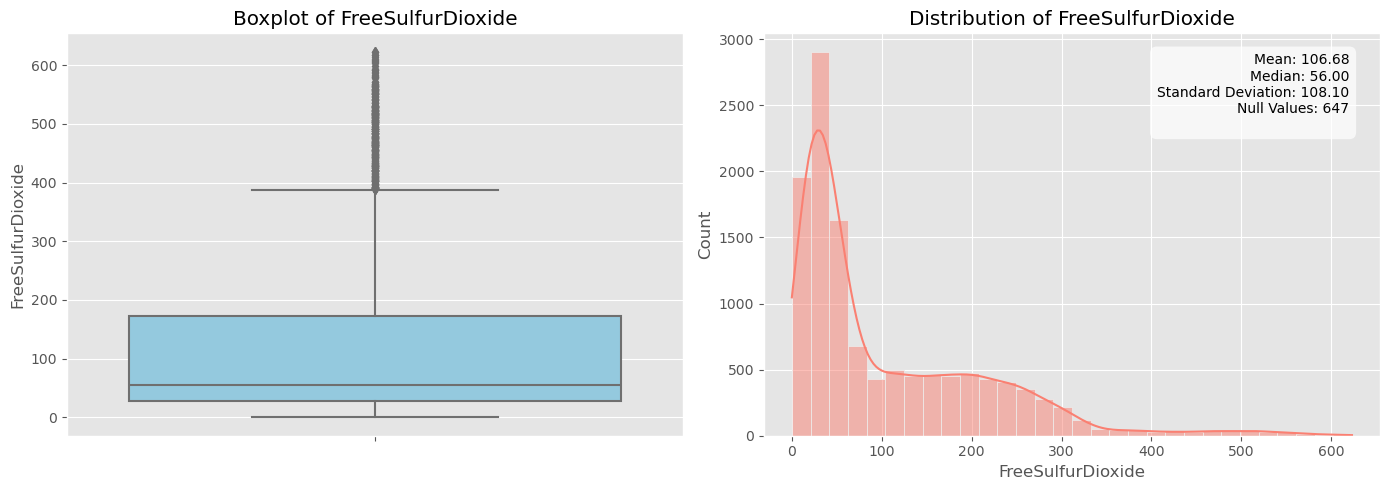

In [241]:
plot_boxplot_and_distribution(df, "FreeSulfurDioxide")

- The histogram reveals a right-skewed distribution for Free Sulfur Dioxide, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low Free Sulfur Dioxide content, while a smaller number have significantly higher levels
- With potential outliers included.

TotalSulfurDioxide

Statistics for 'TotalSulfurDioxide':
Mean: 204.31911995376868
Median: 154.0
Standard Deviation: 163.11688079669636
Null Values: 682
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


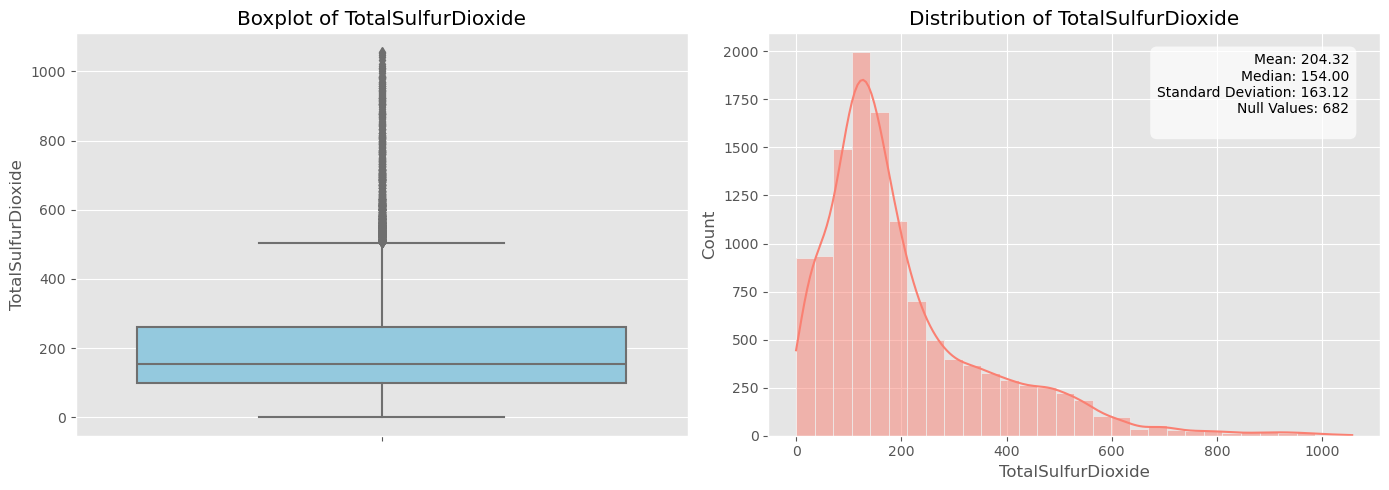

In [242]:
plot_boxplot_and_distribution(df, "TotalSulfurDioxide")

Density

Statistics for 'Density':
Mean: 0.994202718249316
Median: 0.99449
Standard Deviation: 0.026537645472653415
Null Values: 0
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


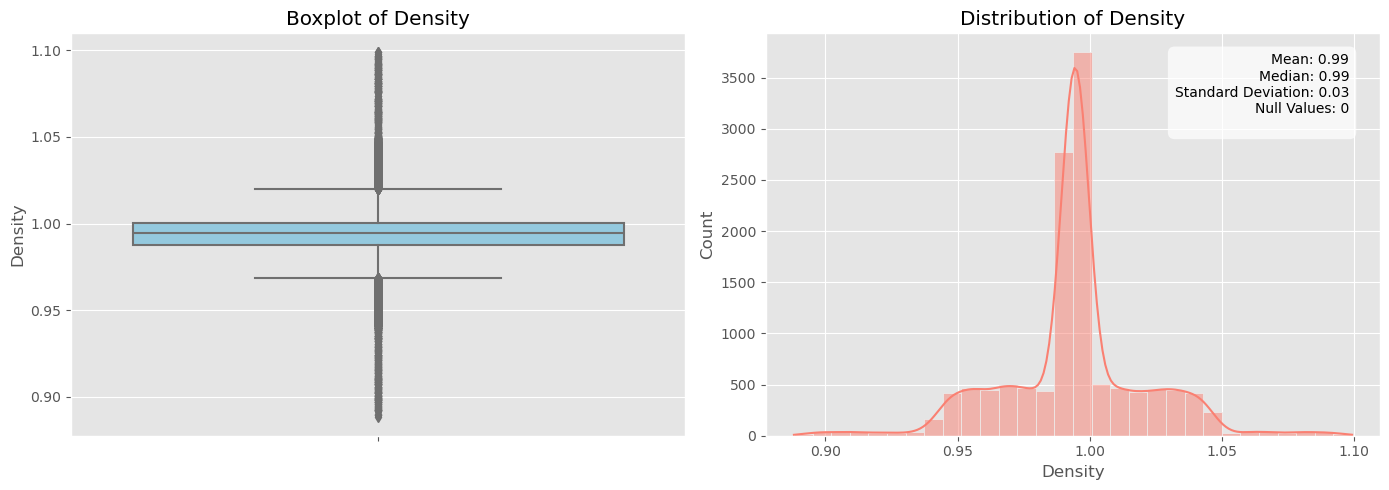

In [243]:
plot_boxplot_and_distribution(df, "Density")

- The histogram shows a nearly normal distribution for Density, with a central peak and symmetrical tails. This suggests that the majority of wines have a Density value close to the mean, with fewer wines having significantly higher or lower values.
- The peak of the histogram suggests that the most common range of Density values is between 0.95 and 1.00.
- With potential outliers included on both sides of median.

pH

Statistics for 'pH':
Mean: 3.2076282258064515
Median: 3.2
Standard Deviation: 0.6796870793671289
Null Values: 395
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


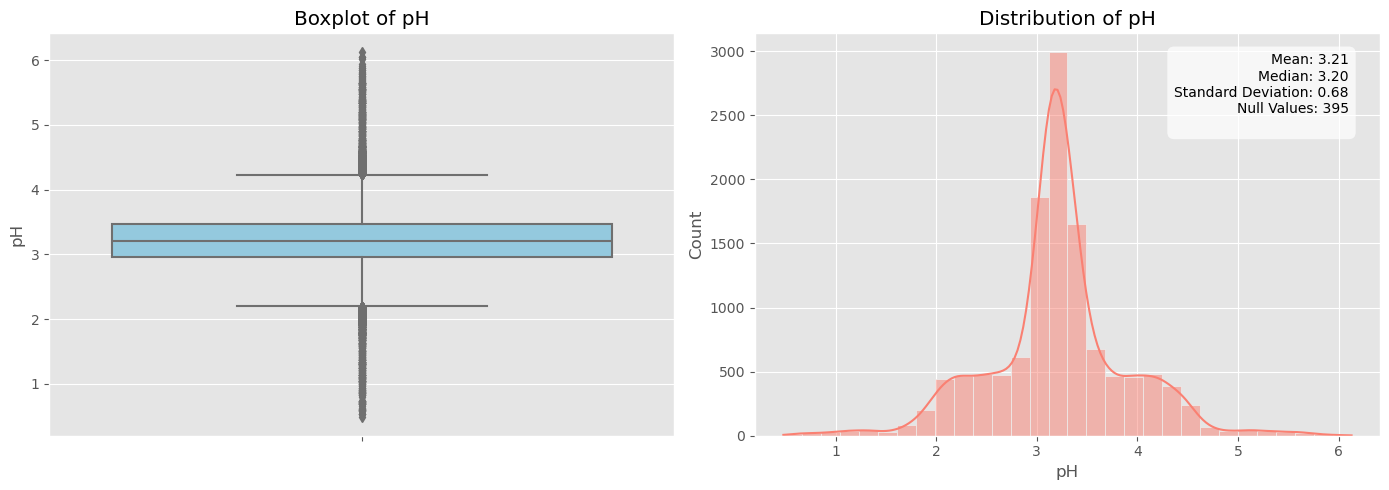

In [244]:
plot_boxplot_and_distribution(df, "pH")

- The histogram shows a nearly normal distribution for pH, with a central peak and symmetrical tails. This suggests that the majority of wines have a pH value close to the mean, with fewer wines having significantly higher or lower values.
- The boxplot reveals a significant number of outliers represented by the individual circles on both sides.

Alcohol

Statistics for 'Alcohol':
Mean: 10.523776643057158
Median: 10.4
Standard Deviation: 3.629154229940884
Null Values: 653
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


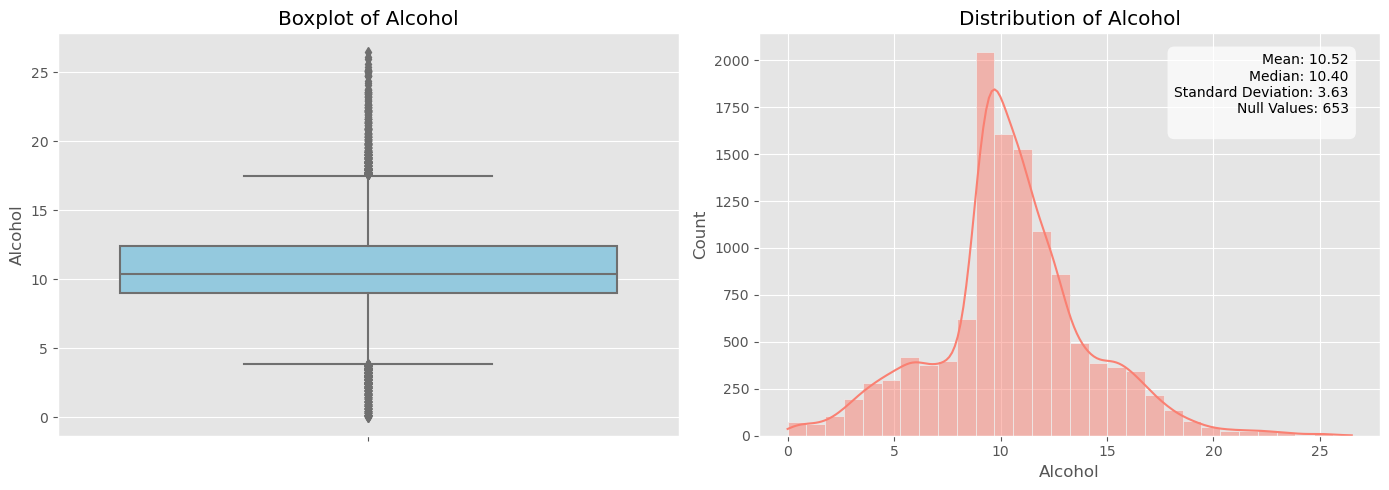

In [245]:
plot_boxplot_and_distribution(df, "Alcohol")

The histogram reveals a slightly right-skewed distribution for Alcohol, indicating that most data points are concentrated at lower values, while a smaller portion extends toward higher values. This suggests that the majority of wines have relatively low Alcohol content, with a few exhibiting significantly higher levels.
The boxplot further supports this right-skewness, as the median (represented by the line inside the box) is positioned closer to the lower end of the distribution. The extended right whisker highlights the presence of outliers or extreme values.

AcidIndex"

Statistics for 'AcidIndex':
Mean: 7.772723720203205
Median: 8.0
Standard Deviation: 1.3239263711757092
Null Values: 0
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


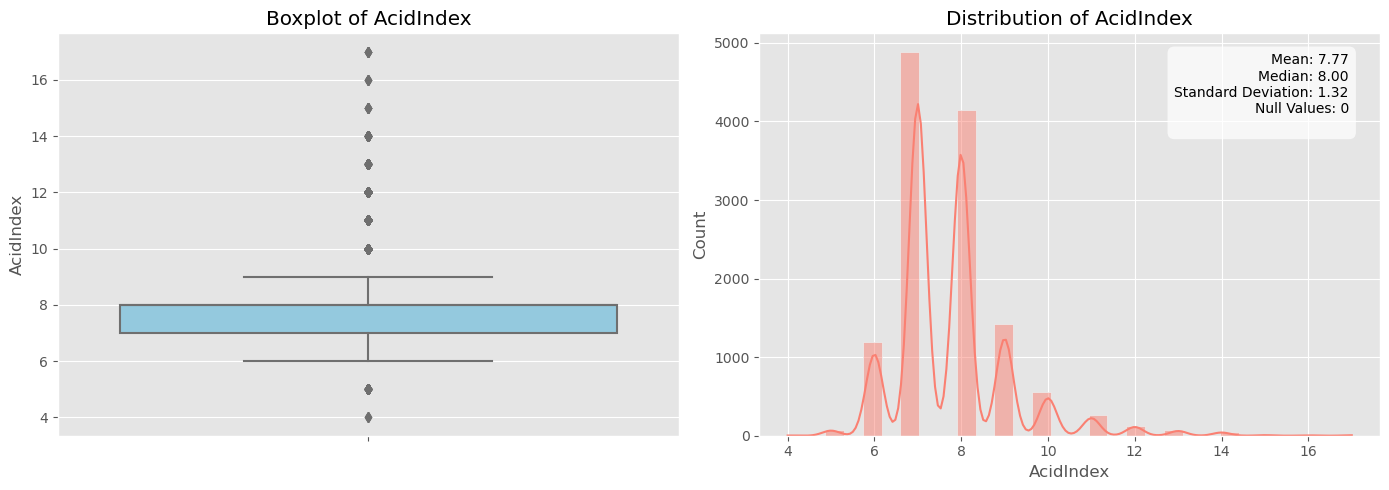

In [246]:
plot_boxplot_and_distribution(df, "AcidIndex")

 The histogram reveals a right-skewed distribution for AcidIndex, indicating that there's a concentration of data points at lower values with a long tail extending towards higher values. This suggests that a majority of wines have a relatively low AcidIndex, while a smaller number have significantly higher values.
- The boxplot confirms the right-skewness, with the median (represented by the line within the box) being closer to the lower end of the distribution. The whisker extending to the right side indicates the presence of outliers or extreme values.

TARGET

Statistics for 'TARGET':
Mean: 3.0290738569753812
Median: 3.0
Standard Deviation: 1.9263682209897157
Null Values: 0
--------------------------------------------------


C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


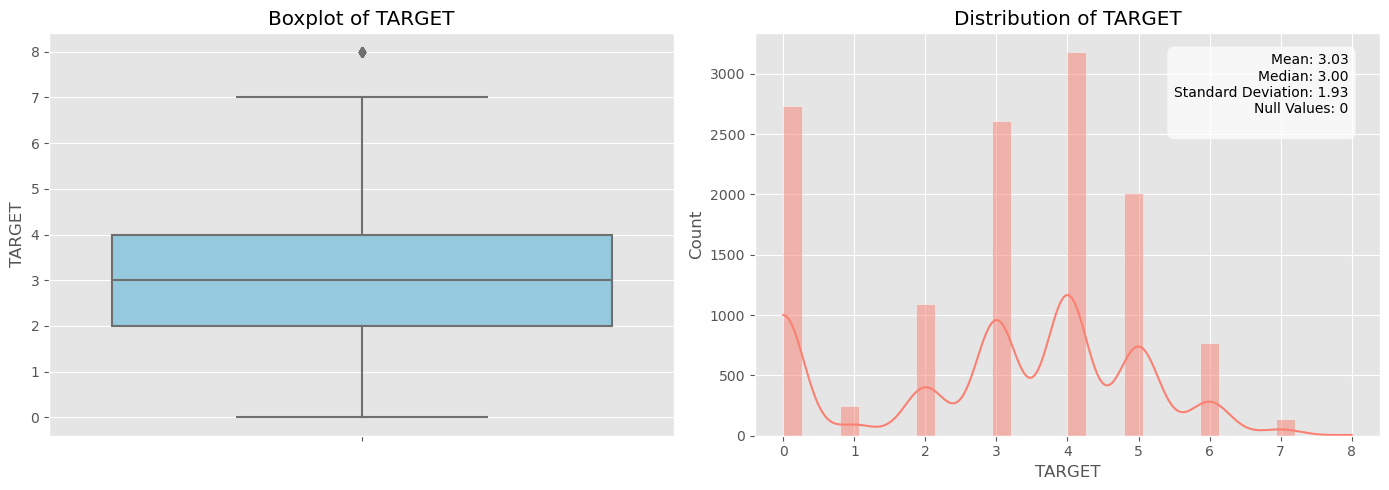

In [247]:
plot_boxplot_and_distribution(df, "TARGET")

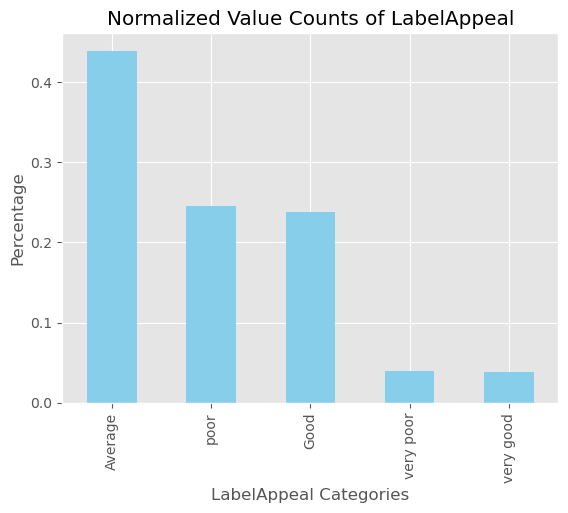

Percentage:-
LabelAppeal
Average      43.90
poor         24.51
Good         23.82
very poor     3.94
very good     3.83
Name: count, dtype: float64

Null Values:
Null values in 'LabelAppeal': 0 out of 12795 total entries
Percentage of null values in 'LabelAppeal': 0.0%


In [248]:

df.LabelAppeal.value_counts(normalize=True).plot.bar(color='skyblue')
plt.title('Normalized Value Counts of LabelAppeal')
plt.ylabel('Percentage')
plt.xlabel('LabelAppeal Categories')
plt.show()

# Print the percentage values
print('Percentage:-')
percentage = (df.LabelAppeal.value_counts() / len(df)) * 100
print(round(percentage, 2))

# Checking for null values in the 'LabelAppeal' column
null_values = df.LabelAppeal.isnull().sum()
total_values = len(df.LabelAppeal)

print("\nNull Values:")
print(f"Null values in 'LabelAppeal': {null_values} out of {total_values} total entries")
print(f"Percentage of null values in 'LabelAppeal': {round((null_values / total_values) * 100, 2)}%")


- The category 0 has the highest Percentage, suggests that a majority of consumers find the wine label appeal to be neutral or slightly positive

STARS

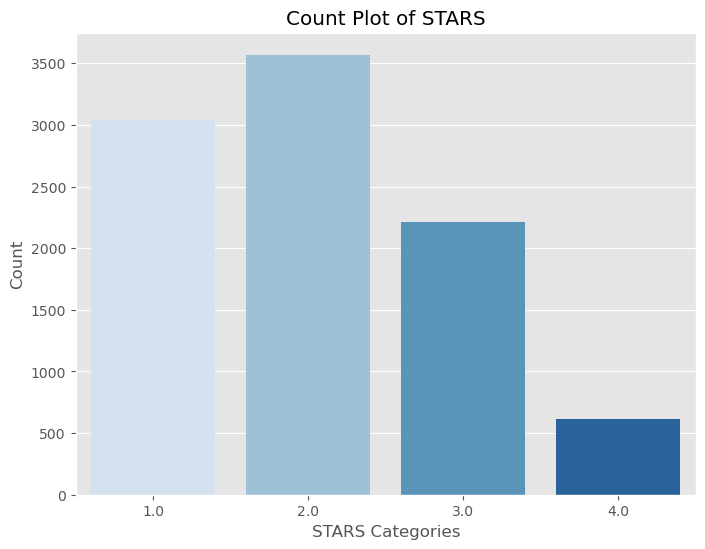

Percentage:-
STARS
2.0    27.90
1.0    23.77
3.0    17.29
4.0     4.78
Name: count, dtype: float64

Null Values:
Null values in 'STARS': 3359 out of 12795 total entries
Percentage of null values in 'STARS': 26.25%


In [249]:


# Plotting the count plot for 'STARS' column
plt.figure(figsize=(8,6))
sns.countplot(x='STARS', data=df, palette='Blues')
plt.title('Count Plot of STARS')
plt.ylabel('Count')
plt.xlabel('STARS Categories')
plt.show()

# Print the percentage values
print('Percentage:-')
percentage = (df.STARS.value_counts() / len(df)) * 100
print(round(percentage, 2))

# Checking for null values in the 'STARS' column
null_values = df.STARS.isnull().sum()
total_values = len(df.STARS)

print("\nNull Values:")
print(f"Null values in 'STARS': {null_values} out of {total_values} total entries")
print(f"Percentage of null values in 'STARS': {round((null_values / total_values) * 100, 2)}%")



- The categories 1 and 2 have the highest counts, suggesting that a majority of the data points fall within these ranges.

Bivrient  Analyisis 

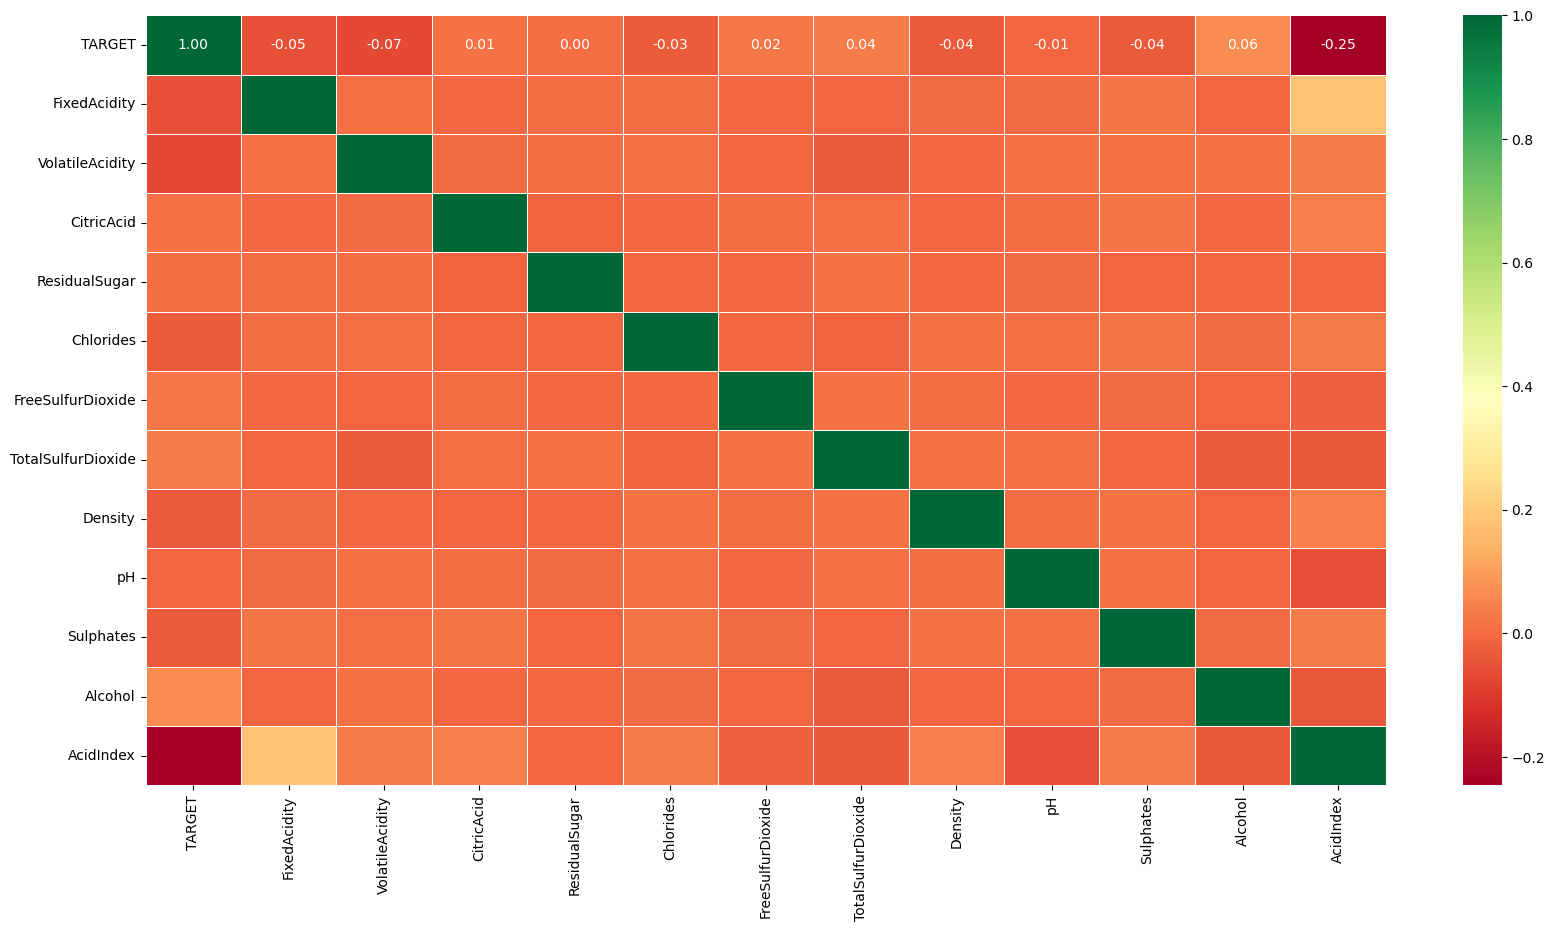

In [250]:


# Specify the columns you want in the heatmap
columns = ['TARGET', 'FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar', 
           'Chlorides', 'FreeSulfurDioxide', 'TotalSulfurDioxide', 'Density', 'pH', 
           'Sulphates', 'Alcohol', 'AcidIndex']

# Compute the correlation matrix for the selected columns
corr = df[columns].corr()

# Set up the matplotlib figure
plt.style.use('default')
plt.figure(figsize=(20,10))

# Plotting the heatmap
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

# Show the plot
plt.show()


Based on the correlation matrix, the variables STARS and LabelAppeal have the strongest positive correlations with TARGET, suggesting that they are the most influential factors in determining the value of TARGET. Alcohol has a weak positive correlation, while the remaining variables have negligible or negative correlations.

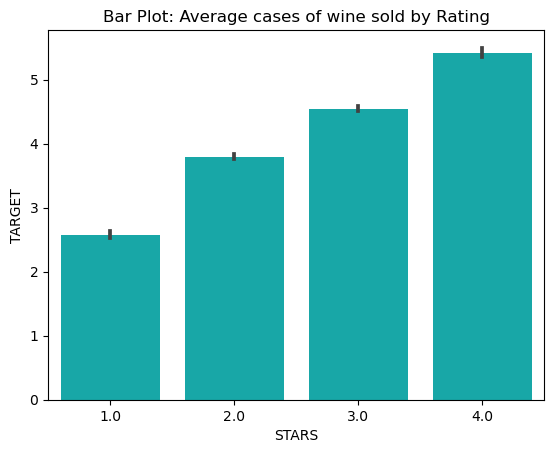

In [251]:
# Plotting a stacked bar plot

# Plotting bargraph  to find the insight depends on STARS and TARGET Column.
sns.barplot(x='STARS', y='TARGET', data=df, color='c')  # code to plot bargraph
plt.title('Bar Plot: Average cases of wine sold by Rating')
plt.show()

It Clearly shows that stars with 4 has highest target

In [252]:
# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(exclude=['number']).columns.tolist()

C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kakol\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


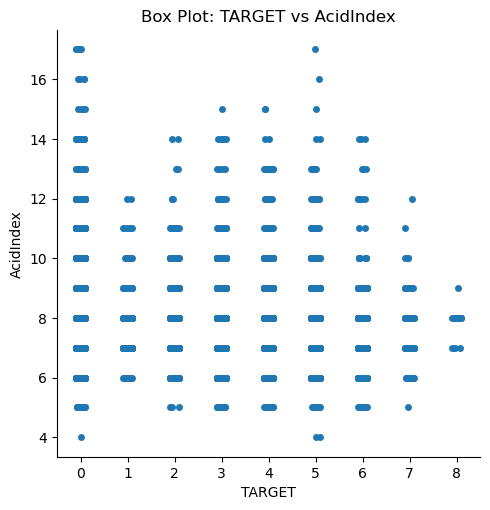

In [253]:

# Create a categorical plot (box plot) to explore 'TARGET' and 'AcidIndex'
sns.catplot(data=df, x='TARGET', y='AcidIndex')

# Add title and labels
plt.title('Box Plot: TARGET vs AcidIndex')
plt.xlabel('TARGET')
plt.ylabel('AcidIndex')

# Show the plot
plt.show()


This scatter plot effectively visualizes how AcidIndex values are distributed across different TARGET categories.
The spread is fairly even, suggesting no clear correlation between TARGET and AcidIndex.

Target vs label

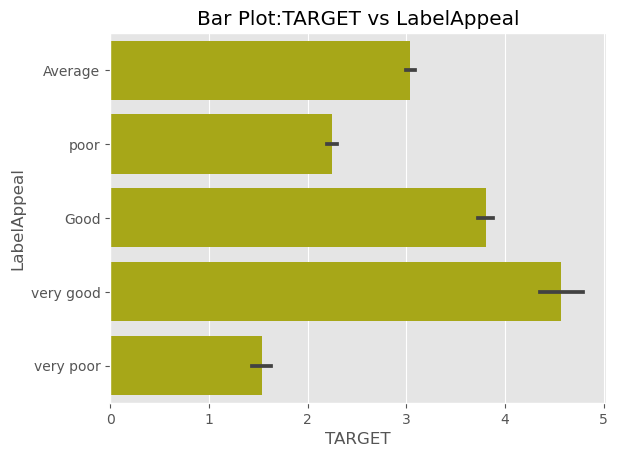

In [254]:

plt.style.use('ggplot')
sns.barplot(x='TARGET' , y='LabelAppeal', data=df, color='y')
plt.title('Bar Plot:TARGET vs LabelAppeal')
plt.show()

LabelAppeal has a strong positive relationship with TARGET. Products rated as having a higher LabelAppeal tend to have higher TARGET values.
Target values increase progressively with better LabelAppeal ratings.
This suggests that LabelAppeal might be a significant factor influencing TARGET.

target vs acid index

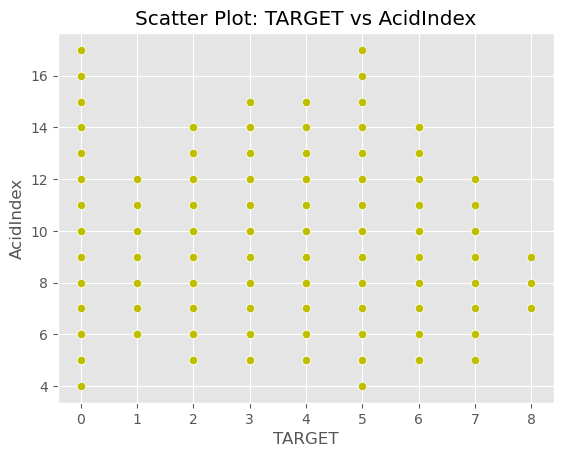

In [255]:

# Use seaborn's scatterplot function
plt.style.use('ggplot')
sns.scatterplot(x='TARGET', y='AcidIndex', data=df, color='y')

# Add title
plt.title('Scatter Plot: TARGET vs AcidIndex')

# Show the plot
plt.show()

The lack of trend suggests that AcidIndex does not strongly correlate with TARGET.

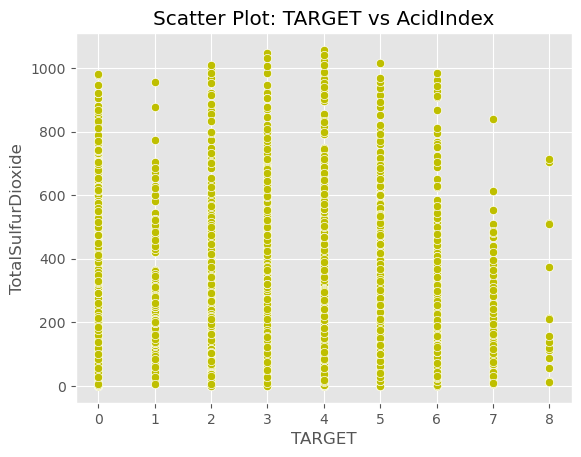

In [256]:

# Use seaborn's scatterplot function
plt.style.use('ggplot')
sns.scatterplot(x='TARGET', y='TotalSulfurDioxide', data=df, color='y')

# Add title
plt.title('Scatter Plot: TARGET vs AcidIndex')

# Show the plot
plt.show()

The scatter plot shows how TotalSulfurDioxide varies across different TARGET categories.
There doesn’t appear to be a clear increasing or decreasing trend.
Negative values suggest data issues that need investigation.

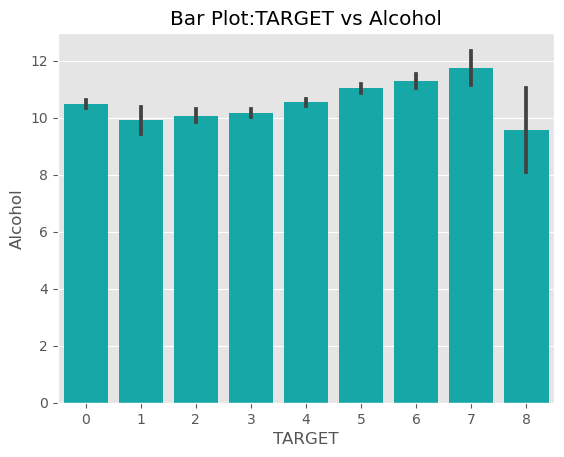

In [257]:
# Plotting bargraph  to find the insight depends on Alcohol and STARS Column.
plt.style.use('ggplot')
sns.barplot(x='TARGET' , y='Alcohol', data=df, color='c')
plt.title('Bar Plot:TARGET vs Alcohol')
plt.show()

- The plot suggests a general trend of higher TARGET values with slighty increasing mean alcohol values.

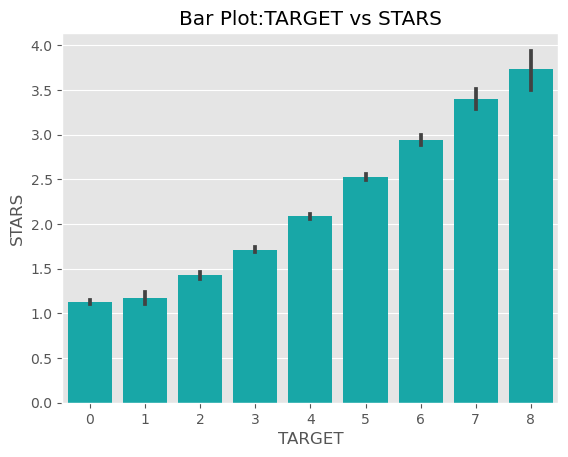

In [258]:
# Plotting bargraph  to find the insight depends on Alcohol and STARS Column.
plt.style.use('ggplot')
sns.barplot(x='TARGET' , y='STARS', data=df, color='c')
plt.title('Bar Plot:TARGET vs STARS')
plt.show()

- The bar chart shows a positive relationship between TARGET (number of cases sold) and STARS (customer ratings). As STARS increase, TARGET also increases, suggesting higher ratings lead to higher sales. This indicates that customer satisfaction is a strong driver of sales in the wine industry

In [259]:
# Create a cross-tabulation (contingency table) of LabelAppeal and STARS
contingency_table = pd.crosstab(df['LabelAppeal'], df['STARS'])

# Display the contingency table
print(contingency_table)




STARS         1.0   2.0   3.0  4.0
LabelAppeal                       
Average      1334  1669  1011  192
Good          448   873   766  310
poor         1008   849   262   29
very good      49   109   152   81
very poor     203    70    21    0


From the above data it clearly tells that for very poor the stars are 0 

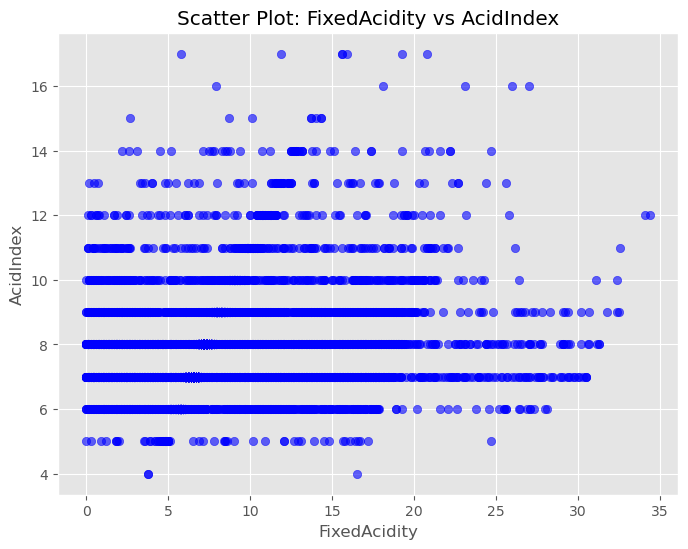

In [260]:
# Scatter plot for FixedAcidity vs AcidIndex
plt.figure(figsize=(8, 6))
plt.scatter(df['FixedAcidity'], df['AcidIndex'], color='blue', alpha=0.6)

# Add title and labels
plt.title('Scatter Plot: FixedAcidity vs AcidIndex')
plt.xlabel('FixedAcidity')
plt.ylabel('AcidIndex')

# Show the plot
plt.show()

Most data points are clustered between FixedAcidity values of -10 to 20.
There is a clear horizontal banding pattern, suggesting that AcidIndex takes only specific discrete values (rather than continuous).
The density of points is higher in the middle of the AcidIndex range (6 to 10), indicating these values are more common.

### Multi VArient analysis 

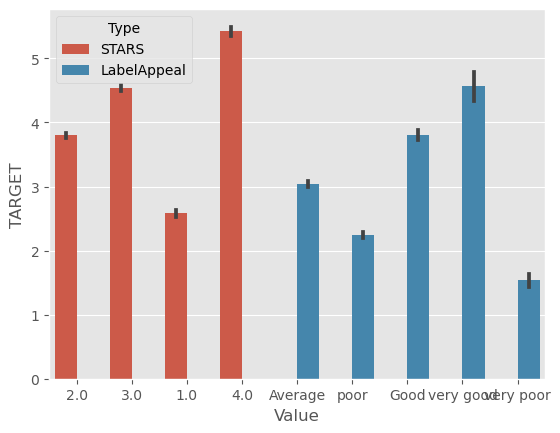

In [261]:
# Graph Plotted to analyse relation between TARGET ,STARS and LabelAppeal
# pd.melt() :- It is used when we have to compare multiple columns
sns.barplot(data=pd.melt(df[['TARGET', 'STARS', 'LabelAppeal']], id_vars='TARGET', value_vars=['STARS', 'LabelAppeal'], var_name='Type', value_name='Value'), x='Value', y='TARGET', hue='Type');
plt.show()

The bar graph indicates that TARGET (number of cases sold) and STARS (customer ratings) have a positive correlation. Target rises in tandem with STARS, indicating that higher ratings translate into more sales. This suggests that in the wine industry, sales are significantly influenced by consumer happines

### Data Preparation:

##### Can create a new variable that combines attributes like Alcohol, AcidIndex, and STARS to derive an overall wine quality score.

In [262]:
df['WineQuality'] = df['Alcohol'] *df['STARS'] * df['AcidIndex']

In [263]:
df

,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS,WineQuality
0,1,3,3.2,1.160,0.98,54.2,0.567,NaN,268.0,0.99280,3.33,0.59,9.9,Average,8,2.0,158.4
1,2,3,4.5,0.160,0.81,26.1,0.425,15.0,327.0,1.02792,3.38,0.70,NaN,poor,7,3.0,NaN
2,4,5,7.1,2.640,0.88,14.8,0.037,214.0,142.0,0.99518,3.12,0.48,22.0,poor,8,3.0,528.0
3,5,3,5.7,0.385,0.04,18.8,0.425,22.0,115.0,0.99640,2.24,1.83,6.2,poor,6,1.0,37.2
4,6,4,8.0,0.330,1.26,9.4,NaN,167.0,108.0,0.99457,3.12,1.77,13.7,Average,9,2.0,246.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12790,16120,0,5.0,0.790,2.01,5.0,0.043,17.0,101.0,1.01077,3.39,0.57,4.9,Good,5,NaN,NaN
12791,16123,5,8.9,0.470,0.29,84.9,0.259,54.0,NaN,0.99518,4.46,1.20,NaN,poor,8,2.0,NaN
12792,16127,4,6.0,0.170,1.10,37.0,0.078,25.0,108.0,0.99076,3.25,NaN,12.3,Average,6,2.0,147.6
12793,16128,3,7.7,0.320,0.12,NaN,0.029,26.0,274.0,0.99060,3.97,0.62,11.0,poor,6,2.0,132.0


In [264]:
import pandas as pd
from sklearn.impute import KNNImputer

# Assuming df is your DataFrame and it contains missing (null) values
# Select only the columns with numeric data for KNN imputation
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Initialize KNN Imputer with k=5 (you can change k based on your needs)
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN Imputer to the numerical columns (it will fill null values)
imputed_df = df.copy()  # Create a copy of the original DataFrame
imputed_df[numerical_columns] = knn_imputer.fit_transform(df[numerical_columns])

# Check the result for null values in the new imputed DataFrame
imputed_df.isnull().sum()


INDEX                 0
TARGET                0
FixedAcidity          0
VolatileAcidity       0
CitricAcid            0
ResidualSugar         0
Chlorides             0
FreeSulfurDioxide     0
TotalSulfurDioxide    0
Density               0
pH                    0
Sulphates             0
Alcohol               0
LabelAppeal           0
AcidIndex             0
STARS                 0
WineQuality           0
dtype: int64

In [ ]:
import numpy as np

# Define the threshold limits for each column (based on domain knowledge)
thresholds = {
    'FixedAcidity': {'lower': 4, 'upper': 15},
    'VolatileAcidity': {'lower': 0.1, 'upper': 1.5},
    'CitricAcid': {'lower': 0, 'upper': 1},
    'ResidualSugar': {'lower': 0, 'upper': 20},
    'Chlorides': {'lower': 0, 'upper': 0.3},
    'FreeSulfurDioxide': {'lower': 0, 'upper': 100},
    'TotalSulfurDioxide': {'lower': 0, 'upper': 200},
    'Density': {'lower': 0.99, 'upper': 1.05},
    'pH': {'lower': 2.9, 'upper': 4},
    'Sulphates': {'lower': 0.2, 'upper': 2},
    'Alcohol': {'lower': 8, 'upper': 15}
}

# Apply capping (Winsorization) to each column
for column, limits in thresholds.items():
    lower_limit = limits['lower']
    upper_limit = limits['upper']
    
    # Cap values that exceed the upper limit
    imputed_df[column] = np.where(imputed_df[column] > upper_limit, upper_limit, imputed_df[column])
    
    # Cap values that fall below the lower limit
    imputed_df[column] = np.where(imputed_df[column] < lower_limit, lower_limit, imputed_df[column])

# Display the cleaned data after capping outliers
imputed_df.head()


Winsorization caps outliers by replacing extreme values with predefined upper and lower thresholds.
It preserves all data points while reducing the influence of outliers that could skew analysis or machine learning models.
Ideal use: When you want to retain the dataset’s integrity but control extreme values affecting model performance



In [ ]:
imputed_df

This method is more suitable when the ordinal data is actually numerical but can still be seen as having some kind of continuous relationship between values.

In [174]:

df_log_transformed = imputed_df.copy()  # Create a copy to preserve the original data
for column in numerical_columns:
    df_log_transformed[column] = np.log(df_log_transformed[column] + 1)

# Display the first few rows of the transformed data
df_log_transformed.head()



,INDEX,TARGET,FixedAcidity,VolatileAcidity,CitricAcid,ResidualSugar,Chlorides,FreeSulfurDioxide,TotalSulfurDioxide,Density,pH,Sulphates,Alcohol,LabelAppeal,AcidIndex,STARS,WineQuality
0,1.0,3.0,1.609438,0.770108,0.683097,3.044522,0.262364,4.207673,5.303305,0.689541,1.465568,0.463734,2.388763,Average,2.197225,1.098612,158.4
1,2.0,3.0,1.704748,0.148420,0.593327,3.044522,0.262364,2.772589,5.303305,0.707011,1.477049,0.530628,2.197225,poor,2.079442,1.386294,191.2
2,4.0,5.0,2.091864,0.916291,0.631272,2.760010,0.036332,4.615121,4.962845,0.690734,1.415853,0.392042,2.772589,poor,2.197225,1.386294,528.0
3,5.0,3.0,1.902108,0.325700,0.039221,2.985682,0.262364,3.135494,4.753590,0.691346,1.360977,1.040277,2.197225,poor,1.945910,0.693147,37.2
4,6.0,4.0,2.197225,0.285179,0.693147,2.341806,0.038066,4.615121,4.691348,0.690428,1.415853,1.018847,2.687847,Average,2.302585,1.098612,246.6


The log transformation reduced skewness, making the data more balanced and easier to analyze. It also minimized the impact of outliers while preserving important patterns in the dataset.

##### Uses of One-Hot Encoding:
One-Hot Encoding is used to convert categorical variables into a format that can be easily understood by machine learning algorithms, avoiding any ordinal assumptions between categories.
It allows for preserving the information of each category while representing it numerically for analysis and modeling.

after running the pd.get_dummies() function:

The categorical LabelAppeal column is split into multiple binary columns.
Each new column corresponds to a specific category in LabelAppeal.
These binary columns (with values 0 or 1) can be used for further analysis, modeling, or machine learning algorithms that require numerical input.

In [ ]:
# Apply One-Hot Encoding to the 'LabelAppeal' column
df_encoded = pd.get_dummies(df_log_transformed, columns=['LabelAppeal'], drop_first=False)

# Convert True/False to 1/0
df_encoded = df_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

# Display the first few rows of the updated DataFrame
df_encoded.head



##### Conclusion:
One-Hot Encoding effectively transforms categorical data into a numerical form without introducing any order or hierarchy between categories, making it ideal for machine learning applications.

##### Standardization :It is useful when the feature distribution is Normal or Gaussian. 
##### Normalization : It is useful when we don’t know about the distribution . 
#### we are sure it is not normally  distributed , we are using Normalization  with the test 

In [ ]:


from sklearn.preprocessing import StandardScaler

# Create a copy of the DataFrame to avoid modifying the original df
df_for_model = df_encoded.copy()

# Manually specify the numerical columns
numerical_columns = ['FixedAcidity', 'VolatileAcidity', 'CitricAcid', 'ResidualSugar', 'Chlorides', 
                     'FreeSulfurDioxide', 'TotalSulfurDioxide', 'Density', 'pH', 'Sulphates', 
                     'Alcohol', 'AcidIndex', 'STARS']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply Standardization to selected numerical columns
df_for_model[numerical_columns] = scaler.fit_transform(df_encoded[numerical_columns])

# Display the first few rows of the standardized DataFrame
print("\nStandardized Data:")
df_for_model.head()





Dropping index column as it does not have influence on it 

### Prepped Data Review


In [ ]:
import matplotlib.pyplot as plt
column = "ResidualSugar"

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['ResidualSugar'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

# Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['ResidualSugar'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()


The histogram reveals a right-skewed distribution for Residual Sugar, with most data points concentrated at lower values and a long tail extending toward higher values. This indicates that the majority of wines have relatively low Residual Sugar content, while a smaller portion contains significantly higher levels.

In [ ]:
import matplotlib.pyplot as plt
column = "Chlorides"

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['Chlorides'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

# Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['Chlorides'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()


In [ ]:
import matplotlib.pyplot as plt
column = "FreeSulfurDioxide"

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['FreeSulfurDioxide'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

# Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['FreeSulfurDioxide'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()


Most of the data points fall under 3 to 5 

In [ ]:
import matplotlib.pyplot as plt
column = "TotalSulfurDioxide"

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['TotalSulfurDioxide'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

# Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['TotalSulfurDioxide'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()


- Both the histogram and boxplot indicate a right-skewed distribution for Total Sulfur Dioxide with a concentration of data points at lower values and a significant number of outliers. This suggests that while most wines have a relatively low Total Sulfur Dioxide content, there are a few exceptional wines with much higher levels.

In [ ]:
import matplotlib.pyplot as plt
column = "pH'"

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['pH'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

#Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['pH'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()

- The histogram and boxplot show a nearly normal distribution for pH with a concentration of data points around the median value. There are a few outliers present.

In [ ]:
import matplotlib.pyplot as plt
column = 'Sulphates'

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['Sulphates'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

#Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['Sulphates'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()

- Overall, both the histogram and boxplot indicate a right-skewed distribution for Sulphates with a concentration of data points at lower values and a single outlier. This suggests that while most wines have a relatively low Sulphate content, there is one exceptional wine with a much higher level.

In [ ]:
import matplotlib.pyplot as plt
column = 'STARS'

# Create Histogram for the selected column
plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed['STARS'], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

#Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['STARS'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()

- The category .1.2has the highest count, suggesting that the majority of the data points fall within this range.

import matplotlib.pyplot as plt
column = 'Alcohol'


plt.figure(figsize=(10, 5))
plt.hist(df_log_transformed["Alcohol"], bins=5, edgecolor='black')
plt.xlabel(column)
plt.ylabel('Frequency')
plt.title(f'Histogram for {column}')  # Corrected string formatting
plt.show()

#Create Box Plot for the selected column
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log_transformed['Alcohol'])
plt.title(f'Box Plot for {column}')  # Corrected string formatting
plt.show()

MULTIVARIENT ANALYSIS

In [ ]:
# Plots bar chart
sns.barplot(imputed_df, x="STARS", y="TARGET")
plt.xlabel("STARS")
plt.ylabel("TARGET")
plt.title("Distribution between TARGET and STARS")
plt.show()

The bar graph shows a positive correlation between TARGET (number of cases sold) and STARS (customer ratings). As STARS increase, TARGET also rises, suggesting that higher ratings lead to more sales. This highlights the strong influence of customer satisfaction on wine sales

In [ ]:
# plots barplot
sns.barplot(imputed_df, x="LabelAppeal", y="TARGET")
plt.xlabel("LabelAppeal")
plt.ylabel("TARGET")
plt.title("Distribution between TARGET and LabelAppeal")
plt.show()

-  Each LabelAppeal category's average TARGET value is shown by bars that show a sharp upward trend, suggesting that wines with higher LabelAppeal ratings often sell far more cases.

In [ ]:
# plots violen plot
sns.catplot(imputed_df, x = "TARGET", y= "AcidIndex" ,kind = "violin")
plt.title(f" Distribution of TARGET across AcidIndex")
plt.xlabel("TARGET")
plt.ylabel("AcidIndex")
plt.show()

The graph provides clear insights since there are no null values, maintaining the same trend as observed in the pre-data preparation EDA.

#### CONCLUSION:
The data preparation adjustments significantly improved the dataset for machine learning by ensuring completeness, reducing skewness, and minimizing the impact of outliers. These improvements lead to better model accuracy, reduced bias, and enhanced interpretability of results.

When the TARGET (sales) is high, both Label Appeal and STARS ratings tend to be very high and excellent.

When the sales are zero, the AcidIndex is at its highest.

Higher sales are associated with a higher percentage of FreeSulfurDioxide.

Wines with the most sales tend to have the highest Density.

Wines with a higher alcohol content often have a Label Appeal rating of Very High.

Higher alcohol content is also linked to STARS ratings of Excellent.

Wines with a Very High Label Appeal tend to have the highest sales, while those with the lowest Label Appeal see the least sales.

Similarly, wines with Excellent ratings in STARS achieve the highest sales, while those with lower ratings have the least.

The most common Label Appeal rating is Medium, while Very High is the least frequent.

Wines with Good STARS ratings have the highest percentage of sales, whereas Excellent ratings have the lowest.

Citations:   For refernce of wine limit values https://en.wikipedia.org/wiki/Phenolic_content_in_wine#Origin_of_the_phenolic_compounds
             For Eda work  https://www.geeksforgeeks.org/what-is-exploratory-data-analysis/?ref=shm
             
             For Understanding of the Concepts reffered  DAV 6150 module 3 